# Triplet Geometry Analysis: UMAP/t-SNE with Quantitative Metrics

This notebook analyzes embedding triplet geometry: (Image, Unit, Foil)

## Analyses:

### A) Triplet Geometry
- $d^+ = 1 - s(I, U)$ (distance image→unit)
- $d^- = 1 - s(I, \tilde{U})$ (distance image→foil)
- $\gamma = d^- - d^+$ (separation: positive = unit closer to image)

**Hypothesis**: CS-CLIP increases separation $\gamma$ relative to CLIP, especially for relational tags.

### B) Neighborhood Mixing Test (Quantitative)
- For each unit, find kNN in text embedding space
- Measure how often its paired foil appears in kNN
- Should drop after CS-CLIP (foils become more distinguishable)

### C) UMAP Visualization
- Embed text vectors (units + foils), color by tag
- Mark unit-foil pairs with lines
- **Paired with quantitative metrics** (not just visual clustering)

In [1]:
# =============================================================================
# SETUP: Imports and Configuration
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from sklearn.neighbors import NearestNeighbors
import os

# Tueplots for publication-ready figures
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# UMAP/t-SNE
try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("UMAP not installed. Run: pip install umap-learn")
    HAS_UMAP = False

from sklearn.manifold import TSNE

# =============================================================================
# STYLE CONFIGURATION
# =============================================================================

COLORBLIND_PALETTE = [f"#{c}" if not c.startswith("#") else c for c in palettes.paultol_bright]

COLOR_BASELINE = COLORBLIND_PALETTE[-1]  # Grey - CLIP
COLOR_NEGCLIP = COLORBLIND_PALETTE[1]    # Red - NegCLIP
COLOR_OURS = COLORBLIND_PALETTE[2]       # Green - CS-CLIP
COLOR_ENTITY = COLORBLIND_PALETTE[0]     # Blue
COLOR_RELATION = COLORBLIND_PALETTE[4]   # Orange

# Model color mapping
MODEL_COLORS = {
    'CLIP': COLOR_BASELINE,
    'NegCLIP': COLOR_NEGCLIP,
    'CS-CLIP': COLOR_OURS,
}

# Tag colors
TAG_COLORS = {
    '+Obj': COLORBLIND_PALETTE[0],    # Blue
    '+Attr': COLORBLIND_PALETTE[3],   # Yellow
    'Swap': COLORBLIND_PALETTE[1],    # Red
    'Ant': COLORBLIND_PALETTE[4],     # Orange
    'Obj': COLORBLIND_PALETTE[5],     # Magenta
    'Subj': COLORBLIND_PALETTE[6],    # Cyan (if available)
}

def apply_tueplots_style(half_width=False):
    """Apply tueplots ICML 2024 style."""
    plt.rcdefaults()
    if half_width:
        plt.rcParams.update(figsizes.icml2024_half())
    else:
        plt.rcParams.update(figsizes.icml2024_full())
    plt.rcParams.update(fontsizes.icml2024())
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['savefig.dpi'] = 300
    sns.set_context('paper', font_scale=0.9)
    sns.set_style("whitegrid", {'grid.color': '0.9', 'grid.linewidth': 0.4})

apply_tueplots_style()
print("✓ Style configured")

✓ Style configured


In [2]:
# =============================================================================
# LOAD EMBEDDINGS
# =============================================================================

# Configure paths to your embedding files
EMBEDDING_DIR = Path("../../triplet_embeddings")  # Adjust path as needed

# Model embedding files (generated by compute_triplet_embeddings.py)
# Updated to match new naming convention from batch run
EMBEDDING_FILES = {
    'CLIP': EMBEDDING_DIR / '00_baseline_openai_vitb32_triplet_embeddings.npz',
    'NegCLIP': EMBEDDING_DIR / 'negclip_coco_vitb32_triplet_embeddings.npz',
    'CS-CLIP': EMBEDDING_DIR / 'cs_clip_negclip_vitb32_triplet_embeddings.npz',
    # 'SigLIP': EMBEDDING_DIR / 'siglip_vitb16_triplet_embeddings.npz',
    # 'SigLIP2': EMBEDDING_DIR / 'siglip2_vitb16_triplet_embeddings.npz',
}

def load_embeddings(filepath):
    """Load embeddings from NPZ file.
    
    Expected fields (from compute_triplet_embeddings.py):
    - short_correct (unit): partial truth
    - long_correct: full correct truth  
    - long_incorrect (foil): half-truth
    """
    data = np.load(filepath, allow_pickle=True)
    
    result = {
        # Embeddings
        'image_embs': data['image_embs'],
        'unit_embs': data['unit_embs'],  # short_correct
        'foil_embs': data['foil_embs'],  # long_incorrect
        # Metadata
        'sample_ids': data['sample_ids'],
        'conditions': data['conditions'],
        'categories': data['categories'],
        'tags': data['tags'],
        # Texts
        'unit_texts': data['unit_texts'],  # short_correct
        'foil_texts': data['foil_texts'],  # long_incorrect
        # Image-text similarities (always present)
        'sim_image_unit': data['sim_image_unit'],
        'sim_image_foil': data['sim_image_foil'],
        # Text-text similarity (always present)
        'sim_unit_foil': data['sim_unit_foil'],
        # Triplet geometry
        'd_plus': data['d_plus'],
        'd_minus': data['d_minus'],
        'gamma': data['gamma'],
    }
    
    # Load long_correct fields if available (new format)
    if 'long_correct_embs' in data.files:
        result['long_correct_embs'] = data['long_correct_embs']
        result['long_correct_texts'] = data['long_correct_texts']
        result['sim_image_long_correct'] = data['sim_image_long_correct']
        result['sim_unit_long_correct'] = data['sim_unit_long_correct']
        result['sim_long_correct_foil'] = data['sim_long_correct_foil']
    
    return result

# Load all model embeddings
all_embeddings = {}
for model_name, filepath in EMBEDDING_FILES.items():
    if filepath.exists():
        all_embeddings[model_name] = load_embeddings(filepath)
        n_samples = len(all_embeddings[model_name]['sample_ids'])
        has_long_correct = 'long_correct_embs' in all_embeddings[model_name]
        print(f"✓ Loaded {model_name}: {n_samples} triplets, long_correct={has_long_correct}")
    else:
        print(f"⚠ Not found: {filepath}")

print(f"\nLoaded {len(all_embeddings)} models")

✓ Loaded CLIP: 5001 triplets, long_correct=True
✓ Loaded NegCLIP: 5001 triplets, long_correct=True
✓ Loaded CS-CLIP: 5001 triplets, long_correct=True

Loaded 3 models


## Section A: Triplet Geometry Analysis

For each triplet $(I, U, \tilde{U})$:
- $d^+ = 1 - s(I, U)$ — distance to unit (correct)
- $d^- = 1 - s(I, \tilde{U})$ — distance to foil (incorrect)
- $\gamma = d^- - d^+$ — separation (positive = model correctly prefers unit)

**Story**: CS-CLIP should increase $\gamma$, especially for relational tags.

In [3]:
# =============================================================================
# COMPUTE TRIPLET GEOMETRY STATISTICS
# =============================================================================

def compute_geometry_stats(embeddings, model_name):
    """Compute triplet geometry statistics."""
    gamma = embeddings['gamma']
    categories = embeddings['categories']
    tags = embeddings['tags']
    
    stats_records = []
    
    # Overall
    stats_records.append({
        'model': model_name,
        'category': 'Overall',
        'tag': 'All',
        'n': len(gamma),
        'gamma_mean': gamma.mean(),
        'gamma_median': np.median(gamma),
        'gamma_std': gamma.std(),
        'pr_correct': (gamma > 0).mean() * 100,  # Pr[γ > 0]
    })
    
    # By category
    for cat in ['entity', 'relation']:
        mask = categories == cat
        if mask.sum() > 0:
            g = gamma[mask]
            stats_records.append({
                'model': model_name,
                'category': cat.capitalize(),
                'tag': 'All',
                'n': mask.sum(),
                'gamma_mean': g.mean(),
                'gamma_median': np.median(g),
                'gamma_std': g.std(),
                'pr_correct': (g > 0).mean() * 100,
            })
    
    # By tag
    for tag in np.unique(tags):
        mask = tags == tag
        if mask.sum() > 0:
            g = gamma[mask]
            cat = categories[mask][0]  # Get category for this tag
            stats_records.append({
                'model': model_name,
                'category': cat.capitalize(),
                'tag': tag,
                'n': mask.sum(),
                'gamma_mean': g.mean(),
                'gamma_median': np.median(g),
                'gamma_std': g.std(),
                'pr_correct': (g > 0).mean() * 100,
            })
    
    return pd.DataFrame(stats_records)

# Compute stats for all models
all_stats = []
for model_name, embs in all_embeddings.items():
    stats_df = compute_geometry_stats(embs, model_name)
    all_stats.append(stats_df)

if all_stats:
    geometry_stats_df = pd.concat(all_stats, ignore_index=True)
    
    print("="*80)
    print("TRIPLET GEOMETRY STATISTICS")
    print("="*80)
    print("\nOverall and by Category:")
    print(geometry_stats_df[geometry_stats_df['tag'] == 'All'][['model', 'category', 'n', 'gamma_mean', 'pr_correct']].to_string(index=False))
    
    print("\nBy Tag:")
    print(geometry_stats_df[geometry_stats_df['tag'] != 'All'][['model', 'tag', 'n', 'gamma_mean', 'pr_correct']].to_string(index=False))

TRIPLET GEOMETRY STATISTICS

Overall and by Category:
  model category    n  gamma_mean  pr_correct
   CLIP  Overall 5001   -0.019089   31.233753
   CLIP   Entity 2500   -0.011261   39.280000
   CLIP Relation 2501   -0.026917   23.190724
NegCLIP  Overall 5001   -0.005309   47.630474
NegCLIP   Entity 2500    0.000616   56.160000
NegCLIP Relation 2501   -0.011232   39.104358
CS-CLIP  Overall 5001    0.011111   64.587083
CS-CLIP   Entity 2500    0.009498   64.680000
CS-CLIP Relation 2501    0.012723   64.494202

By Tag:
  model   tag    n  gamma_mean  pr_correct
   CLIP +Attr  622   -0.021286   28.938907
   CLIP  +Obj 1878   -0.007935   42.705005
   CLIP   Ant 1244   -0.026947   22.427653
   CLIP  Swap 1257   -0.026901   23.945903
NegCLIP +Attr  622   -0.009584   41.157556
NegCLIP  +Obj 1878    0.003994   61.128860
NegCLIP   Ant 1244   -0.018944   29.501608
NegCLIP  Swap 1257   -0.003600   48.607796
CS-CLIP +Attr  622   -0.005327   44.212219
CS-CLIP  +Obj 1878    0.014409   71.458999
CS-C

/tmp/ipykernel_69148/2862659115.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


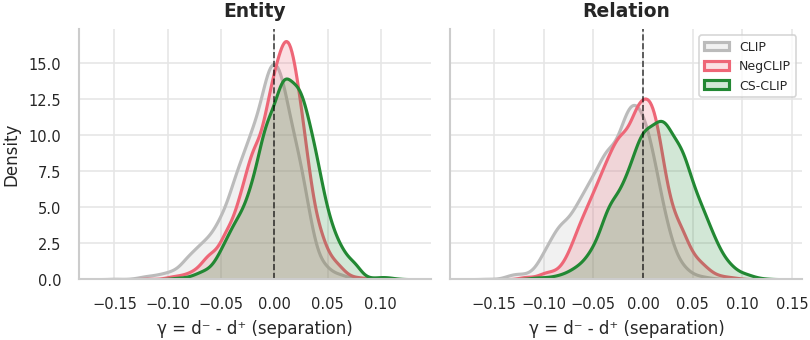

✓ Saved: ../paper_figures/triplet_gamma_distribution.pdf


In [4]:
# =============================================================================
# FIGURE: Gamma Distribution by Model and Category
# =============================================================================

apply_tueplots_style(half_width=False)

if len(all_embeddings) >= 2:
    models = list(all_embeddings.keys())
    
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
    
    for ax, category in zip(axes, ['entity', 'relation']):
        for model_name in models:
            embs = all_embeddings[model_name]
            mask = embs['categories'] == category
            gamma = embs['gamma'][mask]
            
            color = MODEL_COLORS.get(model_name, COLORBLIND_PALETTE[0])
            sns.kdeplot(gamma, ax=ax, label=model_name, color=color, 
                       linewidth=1.5, fill=True, alpha=0.2)
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.set_xlabel('γ = d⁻ - d⁺ (separation)', fontsize=8)
        ax.set_title(category.capitalize(), fontsize=9, fontweight='bold')
        ax.tick_params(axis='both', labelsize=7)
    
    axes[0].set_ylabel('Density', fontsize=8)
    axes[1].legend(loc='upper right', fontsize=6, frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/triplet_gamma_distribution.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    print("✓ Saved: ../paper_figures/triplet_gamma_distribution.pdf")
else:
    print("⚠ Need at least 2 models for comparison")

/tmp/ipykernel_69148/632695183.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


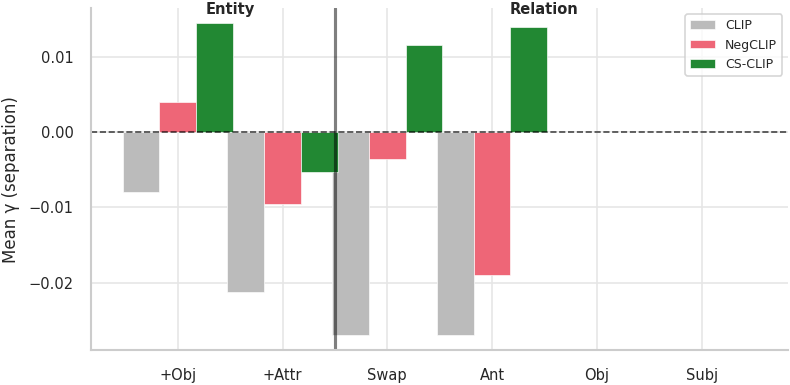

✓ Saved: ../paper_figures/triplet_gamma_by_tag.pdf


In [5]:
# =============================================================================
# FIGURE: Gamma by Tag (Grouped Bar Chart)
# =============================================================================

apply_tueplots_style(half_width=False)

if len(all_embeddings) >= 2 and len(geometry_stats_df) > 0:
    # Filter to specific tags only
    tag_order = ['+Obj', '+Attr', 'Swap', 'Ant', 'Obj', 'Subj']
    tag_df = geometry_stats_df[geometry_stats_df['tag'].isin(tag_order)].copy()
    
    if len(tag_df) > 0:
        fig, ax = plt.subplots(figsize=(5.5, 2.8))
        
        models = list(all_embeddings.keys())
        x = np.arange(len(tag_order))
        width = 0.35
        
        for i, model in enumerate(models):
            model_data = tag_df[tag_df['model'] == model]
            values = [model_data[model_data['tag'] == t]['gamma_mean'].values[0] 
                      if len(model_data[model_data['tag'] == t]) > 0 else 0
                      for t in tag_order]
            
            color = MODEL_COLORS.get(model, COLORBLIND_PALETTE[0])
            offset = (i - len(models)/2 + 0.5) * width
            bars = ax.bar(x + offset, values, width, label=model, color=color, 
                         edgecolor='white', linewidth=0.3)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        
        # Separator between Entity and Relation
        ax.axvline(x=1.5, color='black', linewidth=1.5, alpha=0.5)
        
        ax.set_xticks(x)
        ax.set_xticklabels(tag_order, fontsize=7)
        ax.set_ylabel('Mean γ (separation)', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.legend(loc='upper right', fontsize=6, frameon=True)
        
        # Category labels
        ax.text(0.5, ax.get_ylim()[1] * 0.95, 'Entity', ha='center', fontsize=7, fontweight='bold')
        ax.text(3.5, ax.get_ylim()[1] * 0.95, 'Relation', ha='center', fontsize=7, fontweight='bold')
        
        sns.despine()
        plt.tight_layout()
        plt.savefig('../paper_figures/triplet_gamma_by_tag.pdf', bbox_inches='tight', dpi=300)
        plt.show()
        print("✓ Saved: ../paper_figures/triplet_gamma_by_tag.pdf")

## Section B: Neighborhood Mixing Test (Quantitative)

**Test**: For each unit text embedding, find its kNN in text space. Measure how often its paired foil appears in kNN.

**Hypothesis**: After CS-CLIP training, foils should appear less often in unit neighborhoods (they become more distinguishable).

In [6]:
# =============================================================================
# NEIGHBORHOOD MIXING TEST
# =============================================================================

def compute_neighborhood_mixing(embeddings, k_values=[5, 10, 20, 50]):
    """
    Compute foil-in-kNN rate for each unit.
    
    For each unit embedding, find kNN among ALL text embeddings (units + foils).
    Measure: What fraction of units have their paired foil in their kNN?
    
    Lower is better (foils are more distinguishable).
    """
    unit_embs = embeddings['unit_embs']
    foil_embs = embeddings['foil_embs']
    categories = embeddings['categories']
    tags = embeddings['tags']
    
    n = len(unit_embs)
    
    # Stack all text embeddings: [units; foils]
    all_text_embs = np.vstack([unit_embs, foil_embs])  # (2N, D)
    
    results = []
    
    for k in k_values:
        # Fit kNN on all text embeddings
        nn = NearestNeighbors(n_neighbors=k+1, metric='cosine')  # +1 to exclude self
        nn.fit(all_text_embs)
        
        # For each unit, find its kNN
        distances, indices = nn.kneighbors(unit_embs)
        
        # Check if paired foil (at index i+n) is in kNN
        foil_in_knn = np.zeros(n, dtype=bool)
        for i in range(n):
            foil_idx = i + n  # Foil is at index i+n in all_text_embs
            # indices[i] includes self at position 0, so check indices[i, 1:]
            foil_in_knn[i] = foil_idx in indices[i, 1:k+1]
        
        # Overall rate
        results.append({
            'k': k,
            'category': 'Overall',
            'tag': 'All',
            'foil_in_knn_rate': foil_in_knn.mean() * 100,
            'n': n,
        })
        
        # By category
        for cat in ['entity', 'relation']:
            mask = categories == cat
            if mask.sum() > 0:
                results.append({
                    'k': k,
                    'category': cat.capitalize(),
                    'tag': 'All',
                    'foil_in_knn_rate': foil_in_knn[mask].mean() * 100,
                    'n': mask.sum(),
                })
        
        # By tag
        for tag in np.unique(tags):
            mask = tags == tag
            if mask.sum() > 0:
                results.append({
                    'k': k,
                    'category': categories[mask][0].capitalize(),
                    'tag': tag,
                    'foil_in_knn_rate': foil_in_knn[mask].mean() * 100,
                    'n': mask.sum(),
                })
    
    return pd.DataFrame(results)


# Compute neighborhood mixing for all models
all_mixing = {}
for model_name, embs in all_embeddings.items():
    print(f"Computing kNN mixing for {model_name}...")
    all_mixing[model_name] = compute_neighborhood_mixing(embs)
    all_mixing[model_name]['model'] = model_name

if all_mixing:
    mixing_df = pd.concat(all_mixing.values(), ignore_index=True)
    
    print("\n" + "="*80)
    print("NEIGHBORHOOD MIXING: Foil-in-kNN Rate (%)")
    print("Lower = foils more distinguishable from units")
    print("="*80)
    
    # Pivot for comparison
    pivot = mixing_df[mixing_df['tag'] == 'All'].pivot_table(
        index=['k', 'category'], 
        columns='model', 
        values='foil_in_knn_rate'
    )
    print(pivot.round(1).to_string())

Computing kNN mixing for CLIP...
Computing kNN mixing for NegCLIP...
Computing kNN mixing for CS-CLIP...

NEIGHBORHOOD MIXING: Foil-in-kNN Rate (%)
Lower = foils more distinguishable from units
model        CLIP  CS-CLIP  NegCLIP
k  category                        
5  Entity    18.8     12.8     17.8
   Overall   15.3     10.7     15.2
   Relation  11.8      8.6     12.6
10 Entity    23.8     16.7     21.7
   Overall   20.8     15.1     19.9
   Relation  17.7     13.6     18.1
20 Entity    30.5     20.6     27.8
   Overall   27.7     19.1     25.7
   Relation  24.9     17.7     23.6
50 Entity    41.6     30.0     39.6
   Overall   38.9     27.7     36.7
   Relation  36.1     25.4     33.8


/tmp/ipykernel_69148/4265755494.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


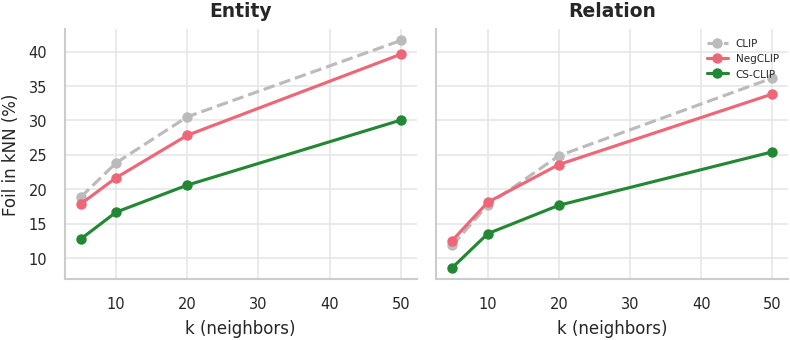

✓ Saved: ../paper_figures/triplet_knn_mixing.pdf


In [21]:
# =============================================================================
# FIGURE: Neighborhood Mixing by k
# =============================================================================

apply_tueplots_style(half_width=False)

if len(all_mixing) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
    
    for ax, category in zip(axes, ['Entity', 'Relation']):
        for model_name in all_mixing.keys():
            df = all_mixing[model_name]
            cat_df = df[(df['category'] == category) & (df['tag'] == 'All')]
            
            color = MODEL_COLORS.get(model_name, COLORBLIND_PALETTE[0])
            linestyle = '--' if model_name == 'CLIP' else '-'
            
            ax.plot(cat_df['k'], cat_df['foil_in_knn_rate'], 
                   label=model_name, color=color, linestyle=linestyle,
                   linewidth=1.5, marker='o', markersize=4)
        
        ax.set_xlabel('k (neighbors)', fontsize=8)
        ax.set_title(category, fontsize=9, fontweight='bold')
        ax.tick_params(axis='both', labelsize=7)
    
    axes[0].set_ylabel('Foil in kNN (%)', fontsize=8)
    axes[1].legend(loc='upper right', fontsize=5, frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/triplet_knn_mixing.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    print("✓ Saved: ../paper_figures/triplet_knn_mixing.pdf")

## Section B.2: Image-to-Text Retrieval Mixing

**Test**: For each image embedding, find its kNN among ALL text embeddings (short-truths + half-truths).
- Measure: How often does the half-truth (foil) appear before/alongside the short-truth (unit)?
- This directly mirrors the Half-Truth benchmark's retrieval task.

**Hypothesis**: CS-CLIP should rank half-truths lower (less likely to appear in top-k for images).

In [8]:
# =============================================================================
# IMAGE-TO-TEXT RETRIEVAL MIXING (Half-Truth style analysis)
# =============================================================================
# Two analyses:
# 1. Pairwise preference: For each (image, unit, foil) triplet, does the model prefer unit over foil?
#    This directly mirrors the Half-Truth benchmark.
# 2. Global retrieval: Among all texts, where does the paired unit/foil rank?

def compute_pairwise_preference(embeddings):
    """
    Compute pairwise preference: Does the model rank short-truth higher than half-truth?
    
    This directly mirrors the Half-Truth benchmark evaluation.
    For each triplet, compare: sim(image, unit) vs sim(image, foil)
    
    Returns accuracy (higher is better) - fraction where unit is preferred.
    """
    # Use pre-computed similarities from the embeddings
    sim_image_unit = embeddings['sim_image_unit']
    sim_image_foil = embeddings['sim_image_foil']
    categories = embeddings['categories']
    tags = embeddings['tags']
    
    # Unit preferred when sim(I, U) > sim(I, F)
    unit_preferred = sim_image_unit > sim_image_foil
    
    results = []
    
    # Overall
    results.append({
        'category': 'Overall',
        'tag': 'All',
        'accuracy': unit_preferred.mean() * 100,  # % where short-truth wins
        'n': len(unit_preferred),
    })
    
    # By category
    for cat in ['entity', 'relation']:
        mask = categories == cat
        if mask.sum() > 0:
            results.append({
                'category': cat.capitalize(),
                'tag': 'All',
                'accuracy': unit_preferred[mask].mean() * 100,
                'n': mask.sum(),
            })
    
    # By tag
    for tag in np.unique(tags):
        mask = tags == tag
        if mask.sum() > 0:
            results.append({
                'category': categories[mask][0].capitalize(),
                'tag': tag,
                'accuracy': unit_preferred[mask].mean() * 100,
                'n': mask.sum(),
            })
    
    return pd.DataFrame(results)


def compute_image_to_text_mixing(embeddings, k_values=[1, 2, 5, 10, 20]):
    """
    Compute half-truth retrieval rate from image perspective (global retrieval).
    
    For each image embedding, find kNN among ALL text embeddings (units + foils).
    This measures: among all possible captions, how often does the half-truth appear in top-k?
    
    NOTE: This is different from pairwise preference. With 2N total captions,
    both unit and foil might rank very low if other captions are more similar.
    """
    image_embs = embeddings['image_embs']
    unit_embs = embeddings['unit_embs']
    foil_embs = embeddings['foil_embs']
    categories = embeddings['categories']
    tags = embeddings['tags']
    
    n = len(image_embs)
    
    # Stack all text embeddings: [units; foils]
    all_text_embs = np.vstack([unit_embs, foil_embs])  # (2N, D)
    
    # Fit kNN on all text embeddings
    max_k = max(k_values)
    nn = NearestNeighbors(n_neighbors=max_k, metric='cosine')
    nn.fit(all_text_embs)
    
    # For each image, find its kNN among text embeddings
    distances, indices = nn.kneighbors(image_embs)
    
    # For each image i:
    #   - unit index is i (in range [0, n))
    #   - foil index is i + n (in range [n, 2n))
    unit_ranks = np.zeros(n, dtype=int)
    foil_ranks = np.zeros(n, dtype=int)
    
    for i in range(n):
        unit_idx = i
        foil_idx = i + n
        
        # Find rank of unit and foil (1-indexed)
        unit_pos = np.where(indices[i] == unit_idx)[0]
        foil_pos = np.where(indices[i] == foil_idx)[0]
        
        unit_ranks[i] = unit_pos[0] + 1 if len(unit_pos) > 0 else max_k + 1
        foil_ranks[i] = foil_pos[0] + 1 if len(foil_pos) > 0 else max_k + 1
    
    results = []
    
    for k in k_values:
        # Check if foil is in top-k for each image
        foil_in_topk = foil_ranks <= k
        # Check if unit is in top-k
        unit_in_topk = unit_ranks <= k
        # Check if foil ranks higher than unit (foil_rank < unit_rank means foil is retrieved first)
        foil_beats_unit = foil_ranks < unit_ranks
        
        # Overall stats
        results.append({
            'k': k,
            'category': 'Overall',
            'tag': 'All',
            'foil_in_topk_rate': foil_in_topk.mean() * 100,
            'unit_in_topk_rate': unit_in_topk.mean() * 100,
            'foil_beats_unit_rate': foil_beats_unit.mean() * 100,
            'n': n,
        })
        
        # By category
        for cat in ['entity', 'relation']:
            mask = categories == cat
            if mask.sum() > 0:
                results.append({
                    'k': k,
                    'category': cat.capitalize(),
                    'tag': 'All',
                    'foil_in_topk_rate': foil_in_topk[mask].mean() * 100,
                    'unit_in_topk_rate': unit_in_topk[mask].mean() * 100,
                    'foil_beats_unit_rate': foil_beats_unit[mask].mean() * 100,
                    'n': mask.sum(),
                })
        
        # By tag
        for tag in np.unique(tags):
            mask = tags == tag
            if mask.sum() > 0:
                results.append({
                    'k': k,
                    'category': categories[mask][0].capitalize(),
                    'tag': tag,
                    'foil_in_topk_rate': foil_in_topk[mask].mean() * 100,
                    'unit_in_topk_rate': unit_in_topk[mask].mean() * 100,
                    'foil_beats_unit_rate': foil_beats_unit[mask].mean() * 100,
                    'n': mask.sum(),
                })
    
    # Also return raw ranks for further analysis
    return pd.DataFrame(results), unit_ranks, foil_ranks


# =============================================================================
# PAIRWISE PREFERENCE (Primary metric - mirrors Half-Truth benchmark)
# =============================================================================
print("="*80)
print("PAIRWISE PREFERENCE: Short-Truth vs Half-Truth")
print("Higher = model prefers short-truth (correct behavior)")
print("="*80)

all_pairwise = {}
for model_name, embs in all_embeddings.items():
    df = compute_pairwise_preference(embs)
    df['model'] = model_name
    all_pairwise[model_name] = df

if all_pairwise:
    pairwise_df = pd.concat(all_pairwise.values(), ignore_index=True)
    
    # Pivot for comparison
    pivot = pairwise_df[pairwise_df['tag'] == 'All'].pivot_table(
        index='category', 
        columns='model', 
        values='accuracy'
    )
    print("\nShort-Truth Preference Accuracy (%):")
    print(pivot.round(1).to_string())
    
    # By tag
    print("\nBy Tag:")
    pivot_tag = pairwise_df[pairwise_df['tag'] != 'All'].pivot_table(
        index='tag', 
        columns='model', 
        values='accuracy'
    )
    print(pivot_tag.round(1).to_string())


# =============================================================================
# GLOBAL RETRIEVAL (Secondary metric - retrieval perspective)
# =============================================================================
print("\n" + "="*80)
print("GLOBAL RETRIEVAL: Rank among ALL captions")
print("Note: With 2N captions, both unit/foil may rank low")
print("="*80)

all_i2t_mixing = {}
all_ranks = {}
for model_name, embs in all_embeddings.items():
    print(f"Computing Image→Text retrieval mixing for {model_name}...")
    df, unit_r, foil_r = compute_image_to_text_mixing(embs)
    df['model'] = model_name
    all_i2t_mixing[model_name] = df
    all_ranks[model_name] = {'unit_ranks': unit_r, 'foil_ranks': foil_r}

if all_i2t_mixing:
    i2t_mixing_df = pd.concat(all_i2t_mixing.values(), ignore_index=True)
    
    # Show the "foil beats unit" rate - this is comparable across models
    print("\nFOIL BEATS UNIT Rate (%) - Lower is better:")
    pivot2 = i2t_mixing_df[(i2t_mixing_df['tag'] == 'All') & (i2t_mixing_df['k'] == 20)].pivot_table(
        index='category', 
        columns='model', 
        values='foil_beats_unit_rate'
    )
    print(pivot2.round(1).to_string())

PAIRWISE PREFERENCE: Short-Truth vs Half-Truth
Higher = model prefers short-truth (correct behavior)

Short-Truth Preference Accuracy (%):
model     CLIP  CS-CLIP  NegCLIP
category                        
Entity    39.4     64.7     56.2
Overall   31.4     64.6     47.6
Relation  23.5     64.5     39.1

By Tag:
model  CLIP  CS-CLIP  NegCLIP
tag                          
+Attr  28.9     44.2     41.2
+Obj   42.8     71.5     61.1
Ant    22.8     65.8     29.5
Swap   24.1     63.2     48.6

GLOBAL RETRIEVAL: Rank among ALL captions
Note: With 2N captions, both unit/foil may rank low
Computing Image→Text retrieval mixing for CLIP...
Computing Image→Text retrieval mixing for NegCLIP...
Computing Image→Text retrieval mixing for CS-CLIP...

FOIL BEATS UNIT Rate (%) - Lower is better:
model     CLIP  CS-CLIP  NegCLIP
category                        
Entity    26.8     23.8     23.6
Overall   35.2     23.3     31.0
Relation  43.5     22.8     38.4


/tmp/ipykernel_69148/1208715564.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


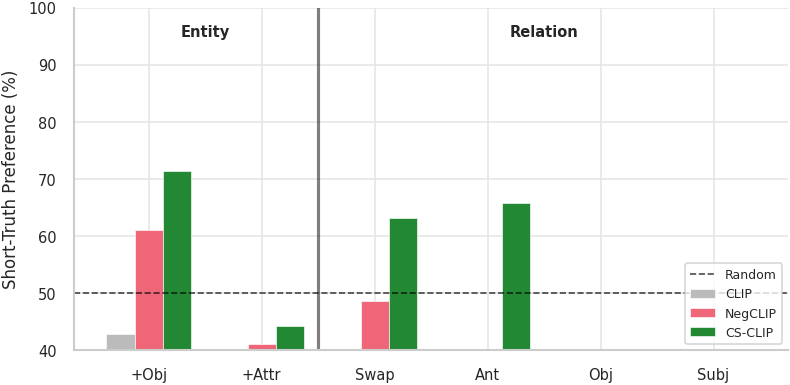

✓ Saved: ../paper_figures/triplet_pairwise_preference.pdf


In [10]:
# =============================================================================
# FIGURE: Pairwise Preference by Tag (Primary metric)
# =============================================================================

apply_tueplots_style(half_width=False)

if len(all_pairwise) >= 2:
    # Filter to specific tags only
    tag_order = ['+Obj', '+Attr', 'Swap', 'Ant', 'Obj', 'Subj']
    tag_df = pairwise_df[pairwise_df['tag'].isin(tag_order)].copy()
    
    if len(tag_df) > 0:
        fig, ax = plt.subplots(figsize=(5.5, 2.8))
        
        models = list(all_pairwise.keys())
        x = np.arange(len(tag_order))
        width = 0.25 if len(models) == 3 else 0.35
        
        for i, model in enumerate(models):
            model_data = tag_df[tag_df['model'] == model]
            values = [model_data[model_data['tag'] == t]['accuracy'].values[0] 
                      if len(model_data[model_data['tag'] == t]) > 0 else 0
                      for t in tag_order]
            
            color = MODEL_COLORS.get(model, COLORBLIND_PALETTE[0])
            offset = (i - len(models)/2 + 0.5) * width
            bars = ax.bar(x + offset, values, width, label=model, color=color, 
                         edgecolor='white', linewidth=0.3)
        
        ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, alpha=0.7, label='Random')
        
        # Separator between Entity and Relation
        ax.axvline(x=1.5, color='black', linewidth=1.5, alpha=0.5)
        
        ax.set_xticks(x)
        ax.set_xticklabels(tag_order, fontsize=7)
        ax.set_ylabel('Short-Truth Preference (%)', fontsize=8)
        ax.set_ylim(40, 100)
        ax.tick_params(axis='y', labelsize=7)
        ax.legend(loc='lower right', fontsize=6, frameon=True)
        
        # Category labels
        ax.text(0.5, 95, 'Entity', ha='center', fontsize=7, fontweight='bold')
        ax.text(3.5, 95, 'Relation', ha='center', fontsize=7, fontweight='bold')
        
        sns.despine()
        plt.tight_layout()
        plt.savefig('../paper_figures/triplet_pairwise_preference.pdf', bbox_inches='tight', dpi=300)
        plt.show()
        print("✓ Saved: ../paper_figures/triplet_pairwise_preference.pdf")

/tmp/ipykernel_69148/3305477409.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


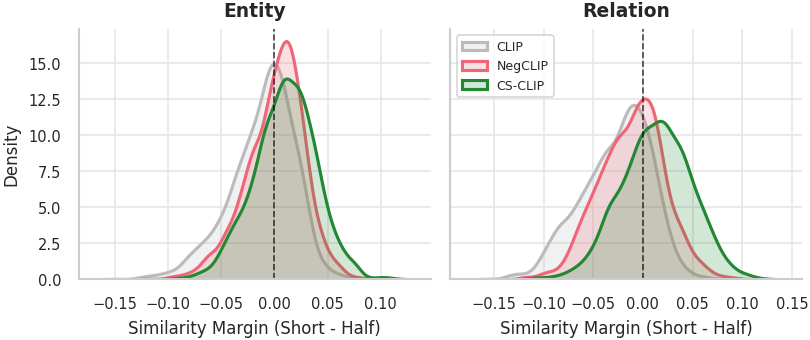


Similarity Margin Statistics (positive = correct preference):
----------------------------------------------------------------------
CLIP:
  Mean margin: -0.0191
  Median margin: -0.0137
  % positive (correct): 31.4%
NegCLIP:
  Mean margin: -0.0053
  Median margin: -0.0018
  % positive (correct): 47.6%
CS-CLIP:
  Mean margin: 0.0111
  Median margin: 0.0119
  % positive (correct): 64.6%

✓ Saved: ../paper_figures/triplet_similarity_margin.pdf


In [11]:
# =============================================================================
# FIGURE: Similarity Margin Distribution (Short-Truth - Half-Truth)
# =============================================================================
# Shows the distribution of sim(I, unit) - sim(I, foil)
# Positive = model correctly prefers short-truth

apply_tueplots_style(half_width=False)

if len(all_embeddings) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
    
    for ax, category in zip(axes, ['entity', 'relation']):
        for model_name, embs in all_embeddings.items():
            mask = embs['categories'] == category
            # Margin = sim(I, unit) - sim(I, foil) = gamma (since gamma = d- - d+ = (1-sim_foil) - (1-sim_unit) = sim_unit - sim_foil)
            # Actually gamma = d- - d+ where d = 1 - sim, so gamma = (1-sim_foil) - (1-sim_unit) = sim_unit - sim_foil
            margin = embs['sim_image_unit'][mask] - embs['sim_image_foil'][mask]
            
            color = MODEL_COLORS.get(model_name, COLORBLIND_PALETTE[0])
            sns.kdeplot(margin, ax=ax, label=model_name, color=color,
                       linewidth=1.5, fill=True, alpha=0.2)
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.set_xlabel('Similarity Margin (Short - Half)', fontsize=8)
        ax.set_title(category.capitalize(), fontsize=9, fontweight='bold')
        ax.tick_params(axis='both', labelsize=7)
    
    axes[0].set_ylabel('Density', fontsize=8)
    axes[1].legend(loc='upper left', fontsize=6, frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/triplet_similarity_margin.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Print statistics
    print("\nSimilarity Margin Statistics (positive = correct preference):")
    print("-" * 70)
    for model_name, embs in all_embeddings.items():
        margin = embs['sim_image_unit'] - embs['sim_image_foil']
        print(f"{model_name}:")
        print(f"  Mean margin: {margin.mean():.4f}")
        print(f"  Median margin: {np.median(margin):.4f}")
        print(f"  % positive (correct): {(margin > 0).mean() * 100:.1f}%")
    
    print("\n✓ Saved: ../paper_figures/triplet_similarity_margin.pdf")

## Section B.3: Full Half-Truth Analysis (Short-Correct, Long-Correct, Long-Incorrect)

**Caption Types** (mirrors Half-Truth benchmark):
- **Short-Correct (unit)**: Partial truth - e.g., "a cat" (just one component)
- **Long-Correct**: Full truth - e.g., "a cat and a dog" (complete correct description)
- **Long-Incorrect (foil)**: Half-truth - e.g., "a cat and a bird" (partially correct, partially wrong)

**Key Questions**:
1. Does the model prefer Long-Correct over Long-Incorrect? (standard Half-Truth test)
2. Does the model prefer Short-Correct over Long-Incorrect? (component understanding)
3. How do the three caption types rank relative to each other?

In [12]:
# =============================================================================
# FULL HALF-TRUTH ANALYSIS: Short-Correct, Long-Correct, Long-Incorrect
# =============================================================================

def compute_full_half_truth_analysis(embeddings):
    """
    Compute preference rates for all three caption types.
    
    This mirrors the Half-Truth benchmark with:
    - short_correct (unit): partial truth
    - long_correct: full truth  
    - long_incorrect (foil): half-truth
    
    Returns DataFrame with various preference metrics.
    """
    # Check if long_correct is available
    if 'sim_image_long_correct' not in embeddings:
        return None
    
    sim_short_correct = embeddings['sim_image_unit']
    sim_long_correct = embeddings['sim_image_long_correct']
    sim_long_incorrect = embeddings['sim_image_foil']
    categories = embeddings['categories']
    tags = embeddings['tags']
    
    n = len(sim_short_correct)
    
    # Pairwise preferences
    long_correct_beats_incorrect = sim_long_correct > sim_long_incorrect  # Standard Half-Truth
    short_correct_beats_incorrect = sim_short_correct > sim_long_incorrect
    long_correct_beats_short = sim_long_correct > sim_short_correct  # Length preference
    
    results = []
    
    # Overall
    results.append({
        'category': 'Overall',
        'tag': 'All',
        'long_correct_vs_incorrect': long_correct_beats_incorrect.mean() * 100,
        'short_correct_vs_incorrect': short_correct_beats_incorrect.mean() * 100,
        'long_correct_vs_short': long_correct_beats_short.mean() * 100,
        'n': n,
    })
    
    # By category
    for cat in ['entity', 'relation']:
        mask = categories == cat
        if mask.sum() > 0:
            results.append({
                'category': cat.capitalize(),
                'tag': 'All',
                'long_correct_vs_incorrect': long_correct_beats_incorrect[mask].mean() * 100,
                'short_correct_vs_incorrect': short_correct_beats_incorrect[mask].mean() * 100,
                'long_correct_vs_short': long_correct_beats_short[mask].mean() * 100,
                'n': mask.sum(),
            })
    
    # By tag
    for tag in np.unique(tags):
        mask = tags == tag
        if mask.sum() > 0:
            results.append({
                'category': categories[mask][0].capitalize(),
                'tag': tag,
                'long_correct_vs_incorrect': long_correct_beats_incorrect[mask].mean() * 100,
                'short_correct_vs_incorrect': short_correct_beats_incorrect[mask].mean() * 100,
                'long_correct_vs_short': long_correct_beats_short[mask].mean() * 100,
                'n': mask.sum(),
            })
    
    return pd.DataFrame(results)


# =============================================================================
# RUN FULL HALF-TRUTH ANALYSIS
# =============================================================================
print("="*80)
print("FULL HALF-TRUTH ANALYSIS: 3-Way Caption Comparison")
print("="*80)

# Check if any model has long_correct data
has_long_correct = any('long_correct_embs' in embs for embs in all_embeddings.values())

if has_long_correct:
    all_full_ht = {}
    for model_name, embs in all_embeddings.items():
        df = compute_full_half_truth_analysis(embs)
        if df is not None:
            df['model'] = model_name
            all_full_ht[model_name] = df
    
    if all_full_ht:
        full_ht_df = pd.concat(all_full_ht.values(), ignore_index=True)
        
        # Table 1: Standard Half-Truth (Long-Correct vs Long-Incorrect)
        print("\n📊 LONG-CORRECT vs LONG-INCORRECT (Standard Half-Truth Test):")
        print("   Higher = model correctly prefers full truth over half-truth")
        pivot_ht = full_ht_df[full_ht_df['tag'] == 'All'].pivot_table(
            index='category', 
            columns='model', 
            values='long_correct_vs_incorrect'
        )
        print(pivot_ht.round(1).to_string())
        
        # Table 2: Short-Correct vs Long-Incorrect
        print("\n📊 SHORT-CORRECT vs LONG-INCORRECT:")
        print("   Higher = model prefers partial truth over half-truth")
        pivot_sc = full_ht_df[full_ht_df['tag'] == 'All'].pivot_table(
            index='category', 
            columns='model', 
            values='short_correct_vs_incorrect'
        )
        print(pivot_sc.round(1).to_string())
        
        # Table 3: Long-Correct vs Short-Correct (length/detail preference)
        print("\n📊 LONG-CORRECT vs SHORT-CORRECT:")
        print("   Higher = model prefers more detailed correct caption")
        pivot_lc = full_ht_df[full_ht_df['tag'] == 'All'].pivot_table(
            index='category', 
            columns='model', 
            values='long_correct_vs_short'
        )
        print(pivot_lc.round(1).to_string())
        
        # By tag
        print("\n" + "="*80)
        print("BY TAG BREAKDOWN:")
        print("="*80)
        tag_df = full_ht_df[full_ht_df['tag'] != 'All']
        for metric, name in [('long_correct_vs_incorrect', 'Long-Correct vs Long-Incorrect'),
                            ('short_correct_vs_incorrect', 'Short-Correct vs Long-Incorrect')]:
            print(f"\n{name}:")
            pivot_tag = tag_df.pivot_table(
                index='tag', 
                columns='model', 
                values=metric
            )
            print(pivot_tag.round(1).to_string())
else:
    print("\n⚠️ No long_correct data available. Re-run compute_triplet_embeddings.py with updated code.")

FULL HALF-TRUTH ANALYSIS: 3-Way Caption Comparison

📊 LONG-CORRECT vs LONG-INCORRECT (Standard Half-Truth Test):
   Higher = model correctly prefers full truth over half-truth
model     CLIP  CS-CLIP  NegCLIP
category                        
Entity    80.5     87.7     82.6
Overall   74.7     90.9     82.5
Relation  68.9     94.1     82.4

📊 SHORT-CORRECT vs LONG-INCORRECT:
   Higher = model prefers partial truth over half-truth
model     CLIP  CS-CLIP  NegCLIP
category                        
Entity    39.4     64.7     56.2
Overall   31.4     64.6     47.6
Relation  23.5     64.5     39.1

📊 LONG-CORRECT vs SHORT-CORRECT:
   Higher = model prefers more detailed correct caption
model     CLIP  CS-CLIP  NegCLIP
category                        
Entity    84.3     80.2     75.6
Overall   83.4     81.6     77.4
Relation  82.5     83.0     79.2

BY TAG BREAKDOWN:

Long-Correct vs Long-Incorrect:
model  CLIP  CS-CLIP  NegCLIP
tag                          
+Attr  71.7     79.9     74.6
+Obj 

/tmp/ipykernel_69148/521410907.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


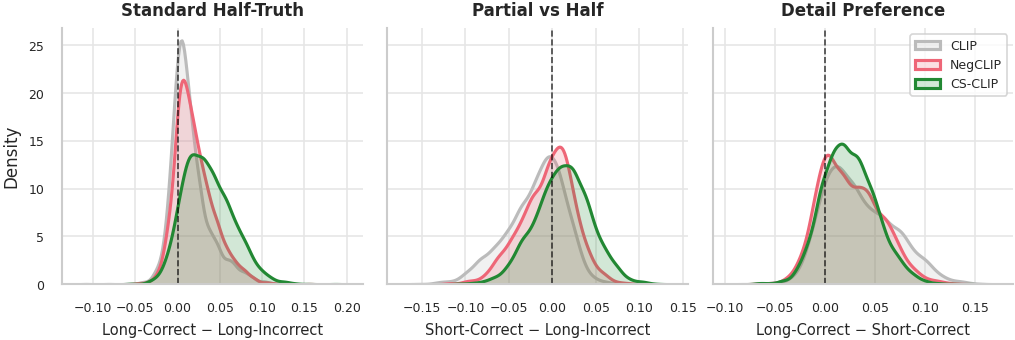

✓ Saved: ../paper_figures/triplet_3way_comparison.pdf


In [13]:
# =============================================================================
# FIGURE: 3-Way Similarity Comparison
# =============================================================================
# Shows similarity distributions for all three caption types

apply_tueplots_style(half_width=False)

if has_long_correct and len(all_full_ht) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True)
    
    comparisons = [
        ('sim_image_long_correct', 'sim_image_foil', 'Long-Correct − Long-Incorrect', 'Standard Half-Truth'),
        ('sim_image_unit', 'sim_image_foil', 'Short-Correct − Long-Incorrect', 'Partial vs Half'),
        ('sim_image_long_correct', 'sim_image_unit', 'Long-Correct − Short-Correct', 'Detail Preference'),
    ]
    
    for ax, (sim1_key, sim2_key, xlabel, title) in zip(axes, comparisons):
        for model_name, embs in all_embeddings.items():
            if sim1_key not in embs or sim2_key not in embs:
                continue
            
            margin = embs[sim1_key] - embs[sim2_key]
            
            color = MODEL_COLORS.get(model_name, COLORBLIND_PALETTE[0])
            sns.kdeplot(margin, ax=ax, label=model_name, color=color,
                       linewidth=1.5, fill=True, alpha=0.2)
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.set_xlabel(xlabel, fontsize=7)
        ax.set_title(title, fontsize=8, fontweight='bold')
        ax.tick_params(axis='both', labelsize=6)
    
    axes[0].set_ylabel('Density', fontsize=8)
    axes[2].legend(loc='upper right', fontsize=6, frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/triplet_3way_comparison.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    print("✓ Saved: ../paper_figures/triplet_3way_comparison.pdf")
else:
    print("⚠️ Skipping 3-way figure: no long_correct data or insufficient models")

/tmp/ipykernel_69148/2775826813.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


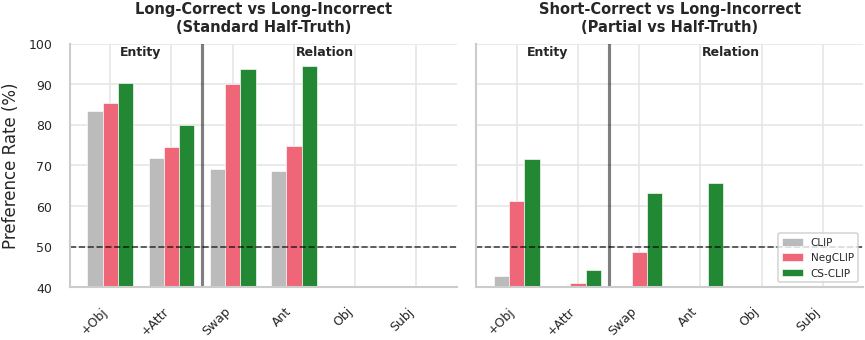

✓ Saved: ../paper_figures/triplet_3way_preference_by_tag.pdf


In [14]:
# =============================================================================
# FIGURE: 3-Way Preference Rates by Tag
# =============================================================================
# Bar chart showing preference rates for each comparison by tag

apply_tueplots_style(half_width=False)

if has_long_correct and len(all_full_ht) >= 2:
    tag_order = ['+Obj', '+Attr', 'Swap', 'Ant', 'Obj', 'Subj']
    tag_df = full_ht_df[full_ht_df['tag'].isin(tag_order)].copy()
    
    if len(tag_df) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)
        
        comparisons = [
            ('long_correct_vs_incorrect', 'Long-Correct vs Long-Incorrect\n(Standard Half-Truth)'),
            ('short_correct_vs_incorrect', 'Short-Correct vs Long-Incorrect\n(Partial vs Half-Truth)'),
        ]
        
        models = list(all_full_ht.keys())
        
        for ax, (metric, title) in zip(axes, comparisons):
            x = np.arange(len(tag_order))
            width = 0.25 if len(models) == 3 else 0.35
            
            for i, model in enumerate(models):
                model_data = tag_df[tag_df['model'] == model]
                values = [model_data[model_data['tag'] == t][metric].values[0] 
                          if len(model_data[model_data['tag'] == t]) > 0 else 0
                          for t in tag_order]
                
                color = MODEL_COLORS.get(model, COLORBLIND_PALETTE[0])
                offset = (i - len(models)/2 + 0.5) * width
                bars = ax.bar(x + offset, values, width, label=model, color=color, 
                             edgecolor='white', linewidth=0.3)
            
            ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.axvline(x=1.5, color='black', linewidth=1.5, alpha=0.5)  # Entity|Relation separator
            
            ax.set_xticks(x)
            ax.set_xticklabels(tag_order, fontsize=6, rotation=45, ha='right')
            ax.set_title(title, fontsize=7, fontweight='bold')
            ax.set_ylim(40, 100)
            ax.tick_params(axis='y', labelsize=6)
        
        axes[0].set_ylabel('Preference Rate (%)', fontsize=8)
        axes[1].legend(loc='lower right', fontsize=5, frameon=True)
        
        # Category labels
        for ax in axes:
            ax.text(0.5, 97, 'Entity', ha='center', fontsize=6, fontweight='bold')
            ax.text(3.5, 97, 'Relation', ha='center', fontsize=6, fontweight='bold')
        
        sns.despine()
        plt.tight_layout()
        plt.savefig('../paper_figures/triplet_3way_preference_by_tag.pdf', bbox_inches='tight', dpi=300)
        plt.show()
        print("✓ Saved: ../paper_figures/triplet_3way_preference_by_tag.pdf")
else:
    print("⚠️ Skipping 3-way preference figure: no long_correct data or insufficient models")

## Section C: UMAP Visualization

**Important**: UMAP is paired with quantitative metrics above. The visualization helps illustrate structure but should not be the primary evidence.

Plot:
- Text embeddings (units and foils)
- Color by tag
- Lines connecting unit-foil pairs

In [15]:
# =============================================================================
# UMAP COMPUTATION
# =============================================================================

def compute_umap_embedding(embeddings, n_neighbors=15, min_dist=0.1, seed=42):
    """Compute UMAP embedding for text vectors (units + foils)."""
    if not HAS_UMAP:
        print("UMAP not available, using t-SNE instead")
        return compute_tsne_embedding(embeddings, seed=seed)
    
    unit_embs = embeddings['unit_embs']
    foil_embs = embeddings['foil_embs']
    
    # Stack: [units; foils]
    all_embs = np.vstack([unit_embs, foil_embs])
    
    # UMAP
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric='cosine',
        random_state=seed,
    )
    
    embedding_2d = reducer.fit_transform(all_embs)
    
    n = len(unit_embs)
    return {
        'unit_2d': embedding_2d[:n],
        'foil_2d': embedding_2d[n:],
    }


def compute_tsne_embedding(embeddings, perplexity=30, seed=42):
    """Compute t-SNE embedding for text vectors."""
    unit_embs = embeddings['unit_embs']
    foil_embs = embeddings['foil_embs']
    
    all_embs = np.vstack([unit_embs, foil_embs])
    
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, len(all_embs) // 4),
        random_state=seed,
        metric='cosine',
    )
    
    embedding_2d = tsne.fit_transform(all_embs)
    
    n = len(unit_embs)
    return {
        'unit_2d': embedding_2d[:n],
        'foil_2d': embedding_2d[n:],
    }


# Compute UMAP for all models
umap_embeddings = {}
for model_name, embs in all_embeddings.items():
    print(f"Computing UMAP for {model_name}...")
    umap_embeddings[model_name] = compute_umap_embedding(embs)

print("\n✓ UMAP embeddings computed")

Computing UMAP for CLIP...


/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for NegCLIP...


/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for CS-CLIP...


/mnt/lustre/work/oh/owl336/.conda/py-311-pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



✓ UMAP embeddings computed


/tmp/ipykernel_69148/2672664426.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


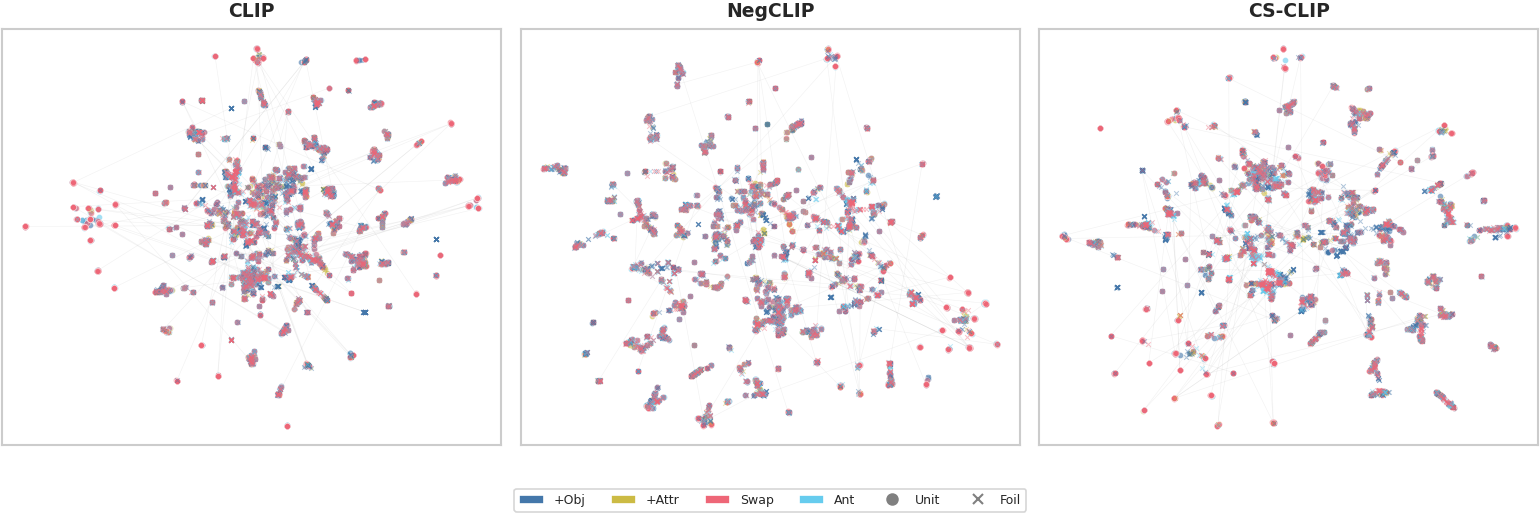

✓ Saved: ../paper_figures/triplet_umap_comparison.pdf


In [16]:
# =============================================================================
# FIGURE: UMAP with Unit-Foil Pairs
# =============================================================================

apply_tueplots_style(half_width=False)

def plot_umap_with_pairs(model_name, embeddings, umap_emb, ax, max_pairs=200):
    """Plot UMAP with unit-foil pairs connected by lines."""
    unit_2d = umap_emb['unit_2d']
    foil_2d = umap_emb['foil_2d']
    tags = embeddings['tags']
    
    n = len(unit_2d)
    indices = np.random.choice(n, min(max_pairs, n), replace=False)
    
    # Plot connecting lines (faded)
    for i in indices:
        ax.plot([unit_2d[i, 0], foil_2d[i, 0]], 
                [unit_2d[i, 1], foil_2d[i, 1]], 
                color='gray', alpha=0.1, linewidth=0.3, zorder=1)
    
    # Plot units (circles)
    for tag in np.unique(tags):
        mask = tags == tag
        color = TAG_COLORS.get(tag, COLORBLIND_PALETTE[0])
        ax.scatter(unit_2d[mask, 0], unit_2d[mask, 1], 
                  c=color, s=8, alpha=0.6, label=f'{tag} (unit)', 
                  marker='o', edgecolors='white', linewidths=0.2, zorder=2)
    
    # Plot foils (x markers, smaller)
    for tag in np.unique(tags):
        mask = tags == tag
        color = TAG_COLORS.get(tag, COLORBLIND_PALETTE[0])
        ax.scatter(foil_2d[mask, 0], foil_2d[mask, 1], 
                  c=color, s=5, alpha=0.4, 
                  marker='x', linewidths=0.5, zorder=2)
    
    ax.set_title(model_name, fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])


if len(all_embeddings) >= 2:
    models = list(all_embeddings.keys())
    fig, axes = plt.subplots(1, len(models), figsize=(3.5 * len(models), 3.5))
    
    if len(models) == 1:
        axes = [axes]
    
    for ax, model_name in zip(axes, models):
        plot_umap_with_pairs(model_name, all_embeddings[model_name], 
                            umap_embeddings[model_name], ax)
    
    # Legend
    legend_elements = []
    for tag in ['+Obj', '+Attr', 'Swap', 'Ant']:
        if tag in TAG_COLORS:
            legend_elements.append(Patch(facecolor=TAG_COLORS[tag], label=tag))
    legend_elements.append(Line2D([0], [0], marker='o', color='gray', label='Unit', 
                                  markerfacecolor='gray', markersize=5, linestyle='None'))
    legend_elements.append(Line2D([0], [0], marker='x', color='gray', label='Foil', 
                                  markersize=5, linestyle='None'))
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=6,
              frameon=True, bbox_to_anchor=(0.5, -0.02))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.savefig('../paper_figures/triplet_umap_comparison.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    print("✓ Saved: ../paper_figures/triplet_umap_comparison.pdf")

/tmp/ipykernel_69148/2592909012.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


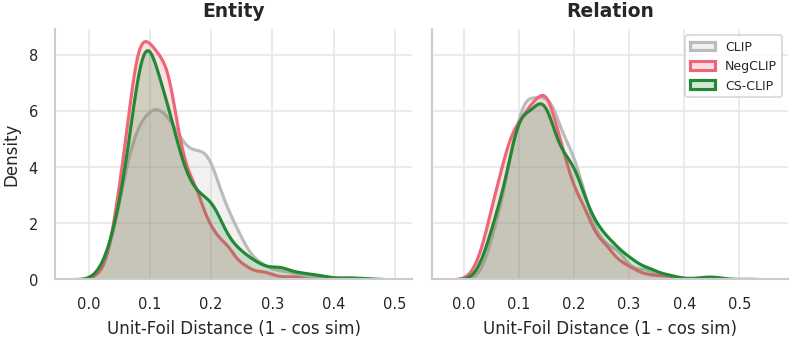


Unit-Foil Distance Statistics:
  CLIP: mean=0.1487, median=0.1416
  NegCLIP: mean=0.1322, median=0.1243
  CS-CLIP: mean=0.1450, median=0.1317

✓ Saved: ../paper_figures/triplet_unit_foil_distance.pdf


In [17]:
# =============================================================================
# FIGURE: Unit-Foil Distance Distribution
# =============================================================================
# Measures how far apart unit-foil pairs are in embedding space
# CS-CLIP should push pairs further apart

apply_tueplots_style(half_width=False)

def compute_unit_foil_distances(embeddings):
    """Compute cosine distance between each unit-foil pair."""
    unit_embs = embeddings['unit_embs']
    foil_embs = embeddings['foil_embs']
    
    # Cosine similarity -> distance
    sim = np.sum(unit_embs * foil_embs, axis=1)
    dist = 1 - sim
    return dist

if len(all_embeddings) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
    
    for ax, category in zip(axes, ['entity', 'relation']):
        for model_name, embs in all_embeddings.items():
            mask = embs['categories'] == category
            distances = compute_unit_foil_distances(embs)[mask]
            
            color = MODEL_COLORS.get(model_name, COLORBLIND_PALETTE[0])
            sns.kdeplot(distances, ax=ax, label=model_name, color=color,
                       linewidth=1.5, fill=True, alpha=0.2)
        
        ax.set_xlabel('Unit-Foil Distance (1 - cos sim)', fontsize=8)
        ax.set_title(category.capitalize(), fontsize=9, fontweight='bold')
        ax.tick_params(axis='both', labelsize=7)
    
    axes[0].set_ylabel('Density', fontsize=8)
    axes[1].legend(loc='upper right', fontsize=6, frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('../paper_figures/triplet_unit_foil_distance.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Print statistics
    print("\nUnit-Foil Distance Statistics:")
    for model_name, embs in all_embeddings.items():
        dist = compute_unit_foil_distances(embs)
        print(f"  {model_name}: mean={dist.mean():.4f}, median={np.median(dist):.4f}")
    
    print("\n✓ Saved: ../paper_figures/triplet_unit_foil_distance.pdf")

In [18]:
# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("="*90)
print("COMPREHENSIVE TRIPLET GEOMETRY SUMMARY")
print("="*90)

if len(all_embeddings) >= 2:
    summary_data = []
    
    for model_name, embs in all_embeddings.items():
        gamma = embs['gamma']
        categories = embs['categories']
        
        # Unit-foil distance
        uf_dist = compute_unit_foil_distances(embs)
        
        # kNN mixing (k=10)
        mixing = all_mixing[model_name]
        knn_overall = mixing[(mixing['k'] == 10) & (mixing['tag'] == 'All') & (mixing['category'] == 'Overall')]['foil_in_knn_rate'].values[0]
        
        for cat in ['Overall', 'Entity', 'Relation']:
            if cat == 'Overall':
                mask = np.ones(len(gamma), dtype=bool)
            else:
                mask = categories == cat.lower()
            
            if mask.sum() == 0:
                continue
            
            knn_rate = mixing[(mixing['k'] == 10) & (mixing['tag'] == 'All') & 
                              (mixing['category'] == cat)]['foil_in_knn_rate'].values
            knn_rate = knn_rate[0] if len(knn_rate) > 0 else np.nan
            
            summary_data.append({
                'Model': model_name,
                'Category': cat,
                'N': mask.sum(),
                'γ mean': gamma[mask].mean(),
                'Pr[γ>0]': (gamma[mask] > 0).mean() * 100,
                'U-F dist': uf_dist[mask].mean(),
                'kNN-10 mix (%)': knn_rate,
            })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.round(3).to_string(index=False))
    
    # Improvement summary
    if 'CLIP' in all_embeddings and 'CS-CLIP' in all_embeddings:
        print("\n" + "="*90)
        print("CS-CLIP vs CLIP IMPROVEMENT")
        print("="*90)
        
        clip_data = summary_df[summary_df['Model'] == 'CLIP'].set_index('Category')
        csclip_data = summary_df[summary_df['Model'] == 'CS-CLIP'].set_index('Category')
        
        for cat in ['Overall', 'Entity', 'Relation']:
            if cat in clip_data.index and cat in csclip_data.index:
                delta_gamma = csclip_data.loc[cat, 'γ mean'] - clip_data.loc[cat, 'γ mean']
                delta_pr = csclip_data.loc[cat, 'Pr[γ>0]'] - clip_data.loc[cat, 'Pr[γ>0]']
                delta_knn = csclip_data.loc[cat, 'kNN-10 mix (%)'] - clip_data.loc[cat, 'kNN-10 mix (%)']
                
                print(f"\n{cat}:")
                print(f"  Δγ (separation): {delta_gamma:+.4f}")
                print(f"  ΔPr[γ>0] (accuracy): {delta_pr:+.1f}pp")
                print(f"  Δ kNN mixing: {delta_knn:+.1f}pp (lower is better)")

COMPREHENSIVE TRIPLET GEOMETRY SUMMARY
  Model Category    N  γ mean  Pr[γ>0]  U-F dist  kNN-10 mix (%)
   CLIP  Overall 5001  -0.019   31.234     0.149          20.776
   CLIP   Entity 2500  -0.011   39.280     0.144          23.840
   CLIP Relation 2501  -0.027   23.191     0.154          17.713
NegCLIP  Overall 5001  -0.005   47.630     0.132          19.896
NegCLIP   Entity 2500   0.001   56.160     0.121          21.680
NegCLIP Relation 2501  -0.011   39.104     0.144          18.113
CS-CLIP  Overall 5001   0.011   64.587     0.145          15.117
CS-CLIP   Entity 2500   0.009   64.680     0.133          16.680
CS-CLIP Relation 2501   0.013   64.494     0.157          13.555

CS-CLIP vs CLIP IMPROVEMENT

Overall:
  Δγ (separation): +0.0302
  ΔPr[γ>0] (accuracy): +33.4pp
  Δ kNN mixing: -5.7pp (lower is better)

Entity:
  Δγ (separation): +0.0208
  ΔPr[γ>0] (accuracy): +25.4pp
  Δ kNN mixing: -7.2pp (lower is better)

Relation:
  Δγ (separation): +0.0396
  ΔPr[γ>0] (accuracy): +41.